# Synthetic Data Experiment Series

## 02 - Hierarchical Two-layer Mixture

This notebook samples synthetic data from a **two-layer Mixture-of-mixture distributions**.

Then compares a mixture of Cylindrical and a mixture-of-mixtures perfomances in learning such data.

**Note:** An extensive grid-search (```02_mom_extensive.py```) was run before to narrow down the grid-search in this didactic notebook.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd

%matplotlib widget
import cyl_lvm as spr
from experiment.synthetic_data import experiment_helper as mod


rng = np.random.RandomState(7)
D_GAUSS = mod.D_GAUSS
D_VMF = mod.D_VMF
N = 10000

### Data Generation


In [2]:
def unit(v):
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        norm = np.linalg.norm(v)
        return v / max(norm, 1e-12)
    else:
        norm = np.linalg.norm(v, axis=-1, keepdims=True)
        return v / np.clip(norm, 1e-12, None)

In [3]:
def spd_from_factor(F, jitter=0.08):
    F = np.asarray(F, dtype=float)
    return F @ F.T + jitter * np.eye(F.shape[0])

l1_means = [
    np.array([-1.0,  0.2,  0.1]),
    np.array([-0.2, -0.4,  0.0]),
    np.array([ 0.5,  0.1, -0.2]),
    np.array([ 1.0, -0.2,  0.2]),
]

l1_factors = [
    np.array([[ 1.10,  0.50,  0.20],
              [ 0.80,  0.60,  0.10],
              [ 0.40,  0.20,  0.80]]),
    np.array([[ 1.00, -0.60,  0.20],
              [-0.70,  1.00, -0.30],
              [ 0.20, -0.50,  0.90]]),
    np.array([[ 1.20,  0.70, -0.20],
              [ 0.50,  0.90,  0.40],
              [-0.10,  0.30,  0.80]]),
    np.array([[ 1.10, -0.50,  0.30],
              [-0.40,  0.80,  0.50],
              [ 0.30,  0.40,  0.90]]),
]

layer1_components = [
    spr.MultivariateGaussian(D_GAUSS, mean=m, covariance=spd_from_factor(F))
    for m, F in zip(l1_means, l1_factors)
]

layer1_mixture = spr.MixtureModel(
    layer1_components,
    weights=np.array([0.15, 0.35, 0.30, 0.20], dtype=float),
    init="k-means",
)

# --- Layer 2: similar directions across groups + one diffuse component ---
layer2_specs = [
    [(unit([1.00, 0.25, 0.05]), 6.0),
     (unit([0.90, 0.40, 0.15]), 4.5),
     (unit([0.80,-0.05, 0.60]), 2.2)],

    [(unit([0.95, 0.15,-0.05]), 5.5),
     (unit([0.88, 0.48, 0.10]), 4.0),
     (unit([0.78,-0.20, 0.58]), 2.0)],

    [(unit([0.92, 0.10, 0.10]), 5.0),
     (unit([0.86, 0.42, 0.22]), 3.8),
     (unit([0.73,-0.10, 0.67]), 1.8)],

    [(unit([0.89, 0.30,-0.02]), 4.8),
     (unit([0.83, 0.50, 0.20]), 3.5),
     (unit([0.70,-0.18, 0.69]), 1.7)],
]

layer2_weights = [
    np.array([0.60, 0.30, 0.10], dtype=float),
    np.array([0.55, 0.30, 0.15], dtype=float),
    np.array([0.45, 0.40, 0.15], dtype=float),
    np.array([0.50, 0.25, 0.25], dtype=float),
]

layer2_mixtures = []
for specs, w in zip(layer2_specs, layer2_weights):
    comps = [spr.VonMisesFisher(D_VMF, mu=mu, kappa=kappa) for mu, kappa in specs]
    layer2_mixtures.append(spr.MixtureModel(comps, weights=w, init="k-means"))

generator = spr.TwoLayerMoM(layer1_mixture=layer1_mixture, layer2_mixtures=layer2_mixtures)
x = generator.sample(N, rng=rng)

In [4]:
x_gauss = x[:, :D_GAUSS]
x_vmf = x[:, D_GAUSS:]

In [5]:
# medium noise setup
sigma_g = 0.15 * np.maximum(x_gauss.std(axis=0, ddof=1), 1e-8)
sigma_v = 0.05

noise_g = rng.normal(0.0, sigma_g, size=(N, D_GAUSS))
noise_v = rng.normal(0.0, sigma_v, size=(N, D_VMF))

x_noisy_gauss = noise_g + x_gauss
x_noisy_vmf = noise_v + x_vmf

# re-project directional block to unit sphere (required for vMF)
x_noisy_vmf = unit(x_noisy_vmf)
x_noisy = np.concatenate((x_noisy_gauss, x_noisy_vmf), axis=1)

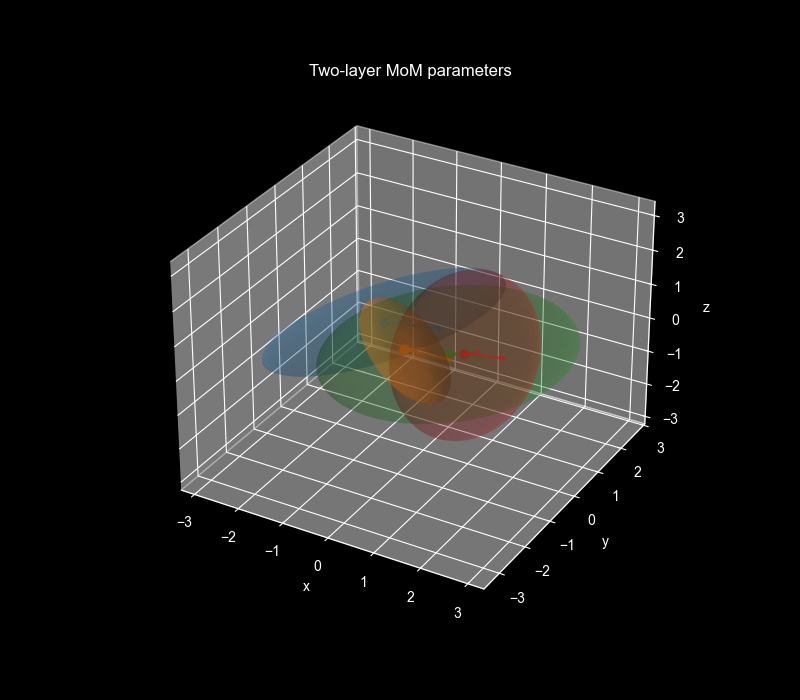

In [6]:
fig, ax = mod.plot_mom_components(generator, arrow_scale=2.0)

### Model Training

**1) Mixture of Cylindrical distributions**


In [7]:
cyl_mixture = mod.cylindrical_mixture_builder_3d(
    n_components=3,
    init="k-means",
    rng=np.random.RandomState(42)
)
cyl_mixture.fit(x)
print("n iteration:", cyl_mixture.n_iter)

n iteration: 30


In [8]:
noisy_cyl_mixture = mod.cylindrical_mixture_builder_3d(
    n_components=3,
    init="k-means",
    rng=np.random.RandomState(42)
)
noisy_cyl_mixture.fit(x_noisy)
print("n iteration:", noisy_cyl_mixture.n_iter)

n iteration: 40


**2) Mixture of Independent Cylindrical distributions**

Selected by Elbow heuristic rather than best score.


In [9]:
indcyl_mixture = mod.ind_cylindrical_mixture_builder_3d(
    n_components=5,
    init="k-means",
    rng=np.random.RandomState(42)
)
indcyl_mixture.fit(x)
print("n iteration:", indcyl_mixture.n_iter)

n iteration: 46


In [10]:
noisy_indcyl_mixture = mod.ind_cylindrical_mixture_builder_3d(
    n_components=5,
    init="k-means",
    rng=np.random.RandomState(42)
)
noisy_indcyl_mixture.fit(x_noisy)
print("n iteration:", noisy_indcyl_mixture.n_iter)

n iteration: 72


**3) Two-Layer Hierarchical Mixture**


In [11]:
mom = mod.mom_builder_3d(
    n_layer1_components=4,
    n_layer2_components=1,
    init_layer1="k-means",
    init_layer2="k-means",
    rng=np.random.RandomState(42)
)
mom.fit(x_gauss, x_vmf)
print("n iteration:", mom.n_iter)

n iteration: 58


In [12]:
noisy_mom = mod.mom_builder_3d(
    n_layer1_components=4,
    n_layer2_components=1,
    init_layer1="k-means",
    init_layer2="k-means",
    rng=np.random.RandomState(42)
)
noisy_mom.fit(x_noisy_gauss, x_noisy_vmf)
print("n iteration:", noisy_mom.n_iter)

n iteration: 64


**4) Isolated-in-training Two-layer Hierarchical Mixture**


In [13]:
iso_mom = mod.mom_iso_builder_3d(
    n_layer1_components=4,
    n_layer2_components=1,
    init_layer1="k-means",
    init_layer2="k-means",
    rng=np.random.RandomState(42)
)
iso_mom.fit(x_gauss, x_vmf)
print("n iteration:", iso_mom.n_iter)

n iteration: 84


In [14]:
noisy_iso_mom = mod.mom_iso_builder_3d(
    n_layer1_components=4,
    n_layer2_components=1,
    init_layer1="k-means",
    init_layer2="k-means",
    rng=np.random.RandomState(42)
)
noisy_iso_mom.fit(x_noisy_gauss, x_noisy_vmf)
print("n iteration:", noisy_iso_mom.n_iter)

n iteration: 93


### Model Comparison

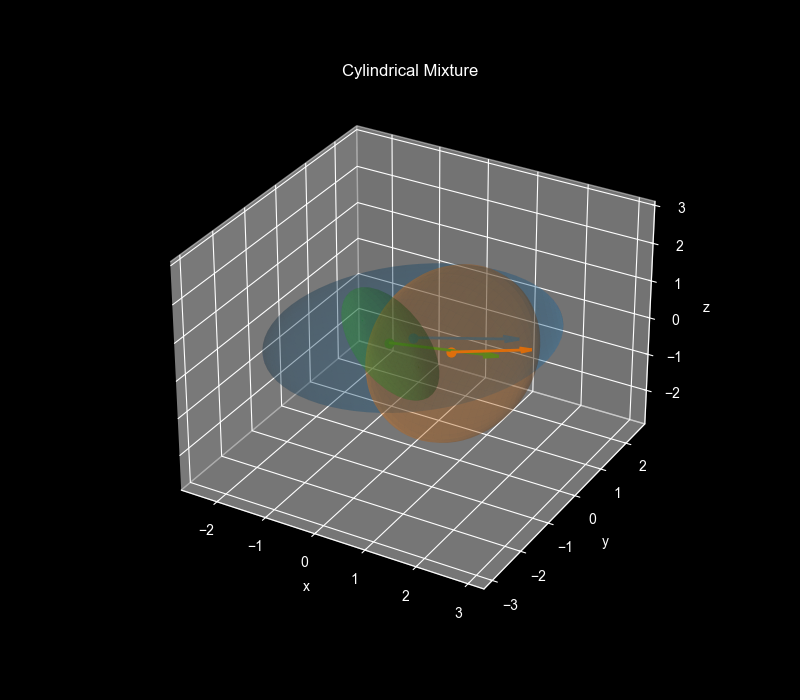

In [15]:
fig, ax = mod.plot_cylindrical_components_3d(cyl_mixture, arrow_scale=2.0, title=f"Cylindrical Mixture")

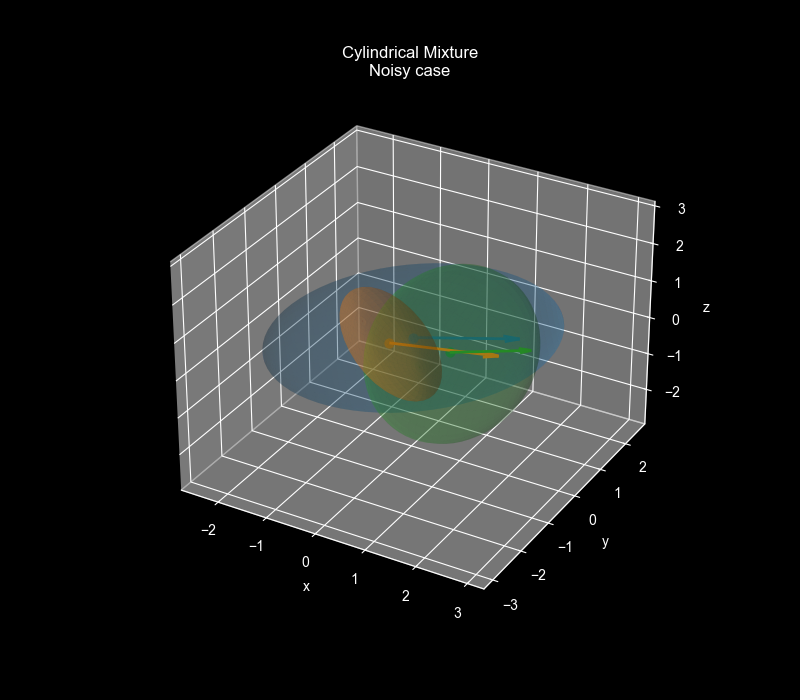

In [16]:
fig, ax = mod.plot_cylindrical_components_3d(noisy_cyl_mixture, arrow_scale=2.0,
                                             title=f"Cylindrical Mixture\nNoisy case")

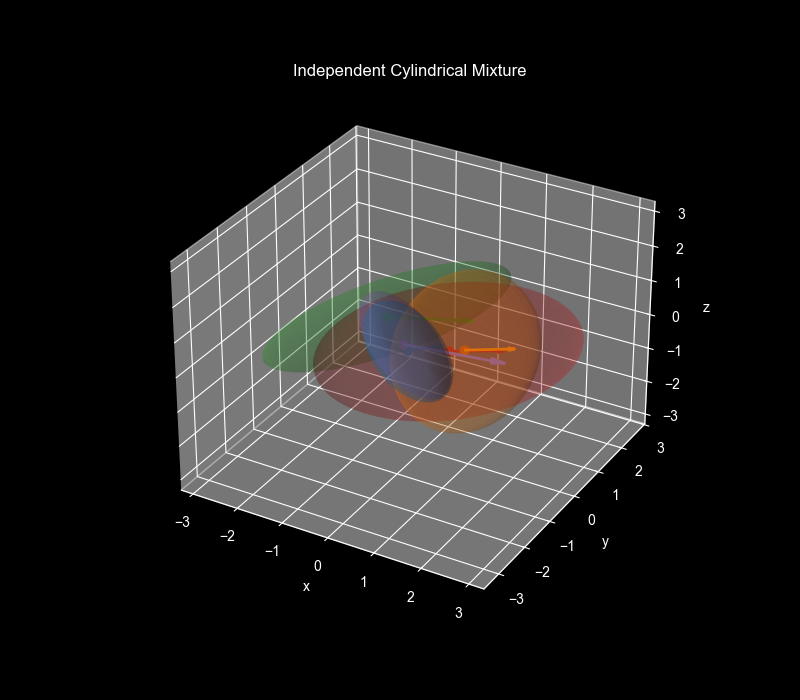

In [17]:
fig, ax = mod.plot_cylindrical_components_3d(indcyl_mixture, arrow_scale=2.0, title="Independent Cylindrical Mixture")

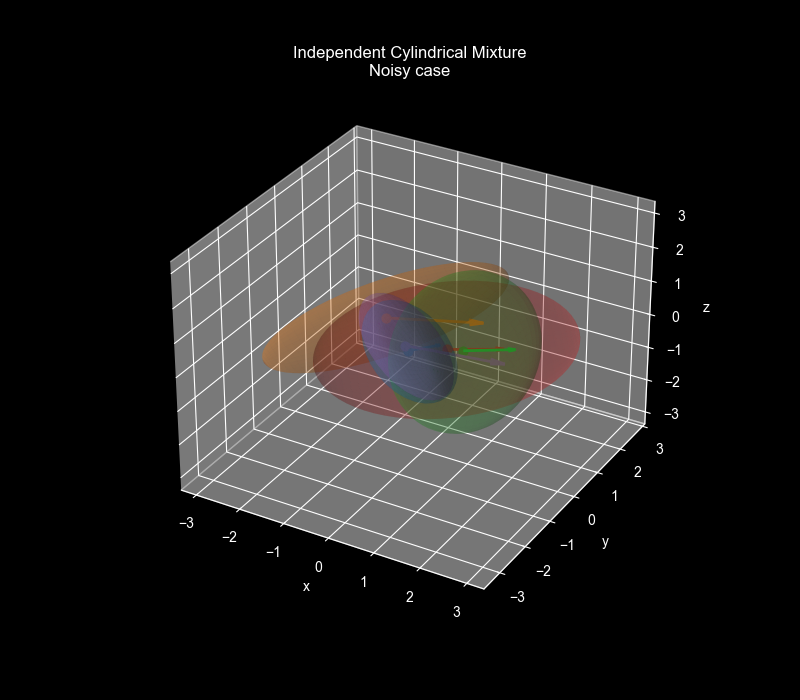

In [18]:
fig, ax = mod.plot_cylindrical_components_3d(noisy_indcyl_mixture, arrow_scale=2.0,
                                             title=f"Independent Cylindrical Mixture\nNoisy case")

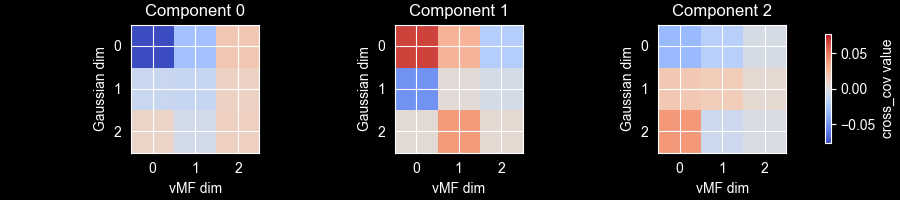

In [19]:
mod.plot_cross_cov_matrices(cyl_mixture.components, cmap="coolwarm")

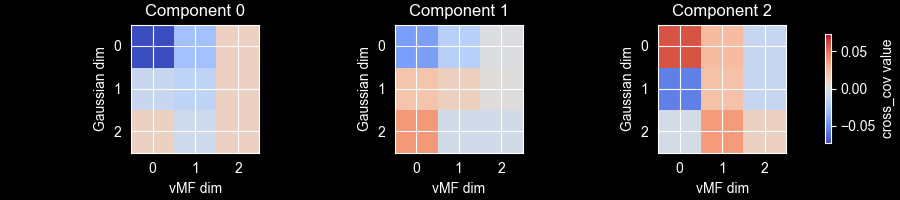

In [20]:
mod.plot_cross_cov_matrices(noisy_cyl_mixture.components, cmap="coolwarm")

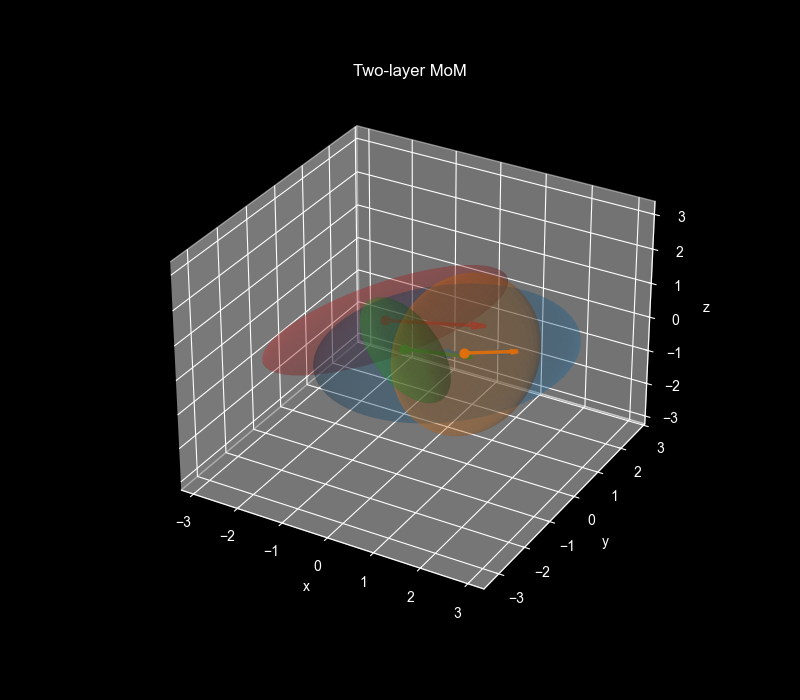

In [21]:
fig, ax = mod.plot_mom_components(mom, arrow_scale=2.0,
                                  title=f"Two-layer MoM")

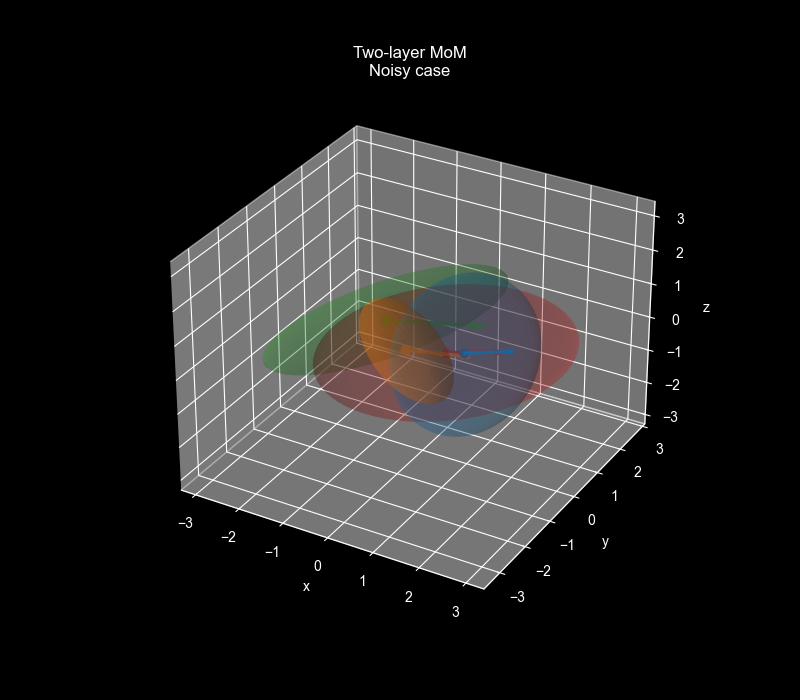

In [22]:
fig, ax = mod.plot_mom_components(noisy_mom, arrow_scale=2.0,
                                  title=f"Two-layer MoM\nNoisy case")

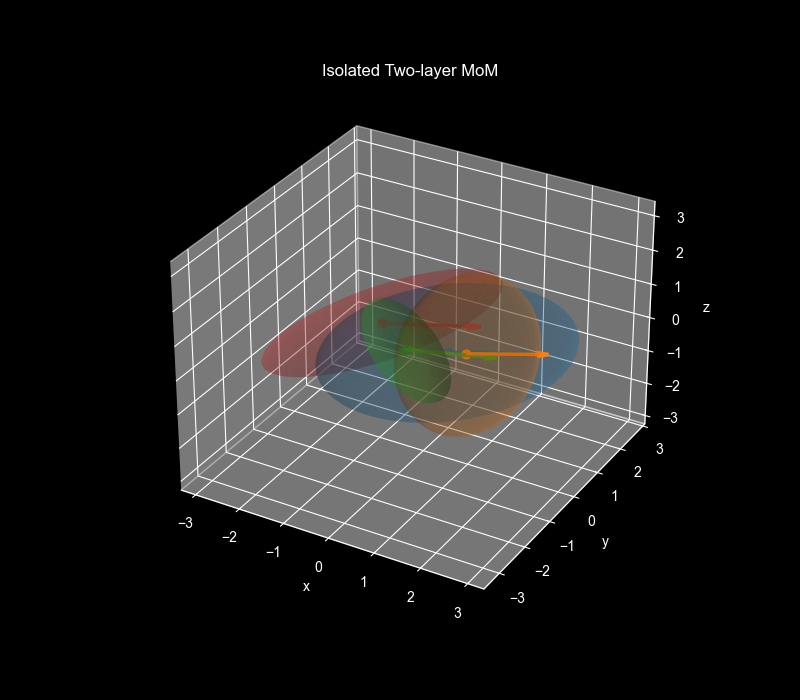

In [23]:
fig, ax = mod.plot_mom_components(iso_mom, arrow_scale=2.0,
                                  title=f"Isolated Two-layer MoM")

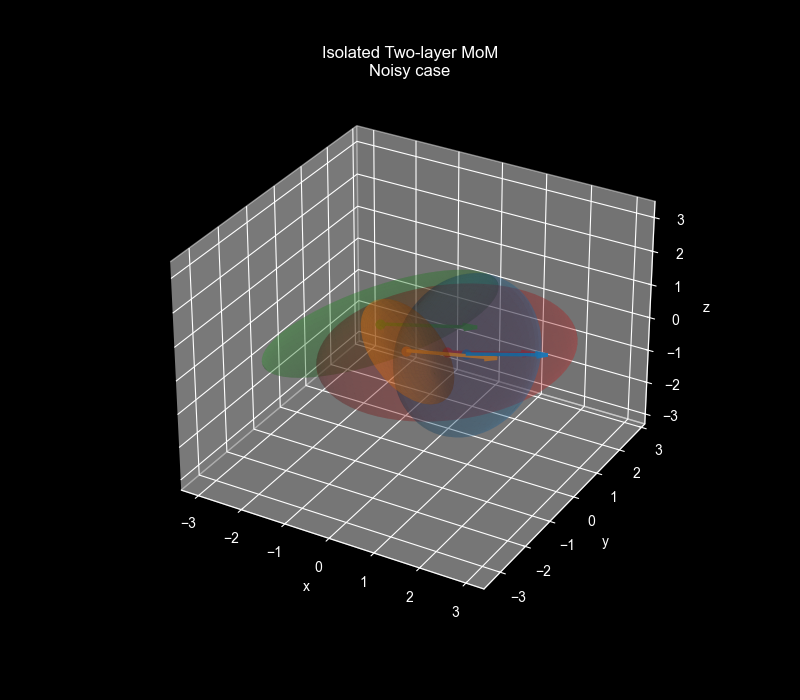

In [24]:
fig, ax = mod.plot_mom_components(noisy_iso_mom, arrow_scale=2.0,
                                  title=f"Isolated Two-layer MoM\nNoisy case")

In [25]:
import pandas as pd

rows = []

def add_case(case_name, x_mix, xg_mom, xv_mom):
    rows.extend([
        {"case": case_name,
            "model": "Cylindrical Mixture",
            "bic": cyl_mixture.bic_score(x_mix),
            "neg_ll": -cyl_mixture.log_pdf(x_mix).sum()},
        {"case": case_name,
            "model": "Ind. Cylindrical Mixture",
            "bic": indcyl_mixture.bic_score(x_mix),
            "neg_ll": -indcyl_mixture.log_pdf(x_mix).sum()},
        {"case": case_name,
            "model": "Two-layer MoM",
            "bic": mom.bic_score(xg_mom, xv_mom),
            "neg_ll": -mom.log_pdf(xg_mom, xv_mom).sum()},
        {"case": case_name,
            "model": "Isolated Two-layer MoM",
            "bic": iso_mom.bic_score(xg_mom, xv_mom),
            "neg_ll": -iso_mom.log_pdf(xg_mom, xv_mom).sum()},
    ])

add_case("Pure signal", x, x_gauss, x_vmf)
add_case("Noisy", x_noisy, x_noisy_gauss, x_noisy_vmf)

df_scores = pd.DataFrame(rows)
df_scores[["bic", "neg_ll"]] = df_scores[["bic", "neg_ll"]].round(0).astype(int)
df_scores

,case,model,bic,neg_ll
0,Pure signal,Cylindrical Mixture,121891,60646
1,Pure signal,Ind. Cylindrical Mixture,120789,60100
2,Pure signal,Two-layer MoM,120826,60178
3,Pure signal,Isolated Two-layer MoM,120903,60216
4,Noisy,Cylindrical Mixture,123602,61502
5,Noisy,Ind. Cylindrical Mixture,122779,61095
6,Noisy,Two-layer MoM,122803,61167
7,Noisy,Isolated Two-layer MoM,122870,61200
